<a href="https://colab.research.google.com/github/LuciusMelillo09/DataScience/blob/main/Unit7/Copy_of_Unit7ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

Polynomial can capture any relationships between variables that isn't strictly linear, relationships that curve, or change direction.

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

It's possible for polynomial elements to overfit the data. Also, since they are more complex, it takes more time for the model to process. In addition, if the relationship between variables is linear, there would be no reason to include a polynomial element.

**Task3**:

What's the point of using b splines?

Using b splines is like using a piecewise function for linear models, they break apart the prediction into knots, or regions, and each "knot" has its own individual regression run on it, to figure out what best fits that specific part of the data. B splines helps prevent overfitting

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

A gaussian process is a way of modeling functions, it is a process that finds all of the possible functions that fit a specific set of data points, then finds a good middleground between all of them to make a function that best fits with the data. A gaussian process chooses where the "knots", or regions, are located to best fit the data

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [ ]:
!pip install preliz

In [ ]:
!pip install bambi

In [3]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import preliz as pz
import pymc as pm
import bambi as bmb

In [4]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')

In [ ]:
poly1 = bmb.Model("height ~ poly(weight, degree=5)", howell)
idata_poly1 = poly1.fit(draws=2000)

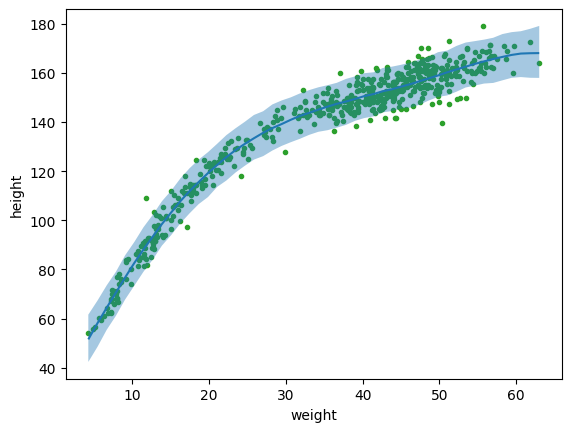

In [6]:
bmb.interpret.plot_predictions(poly1, idata_poly1, "weight", pps=True)
plt.plot(howell.weight, howell.height, "C2.", zorder=-3)

B Spline:

In [ ]:
num_knots = 6
knots = np.linspace(howell.weight.min(), howell.weight.max(), num_knots+2)[1:-1]
model_spline_t = bmb.Model("height ~ bs(weight, degree=3, knots=knots)", howell, family="t")
idata_spline_t = model_spline_t.fit()

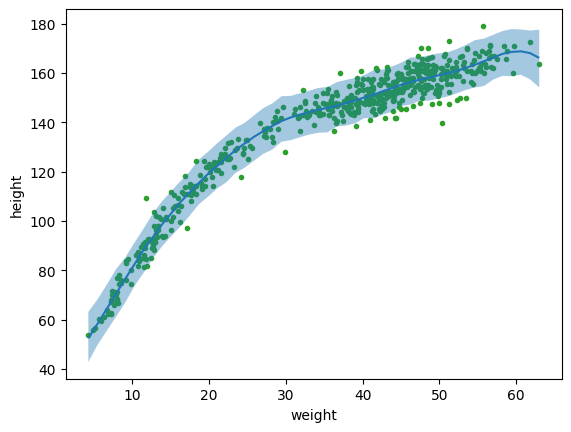

In [8]:
bmb.interpret.plot_predictions(model_spline_t, idata_spline_t, "weight", pps=True)
plt.plot(howell.weight, howell.height, "C2.", zorder=-3)

Gaussian

In [9]:
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    # GEMINI - Convert x_vals to a NumPy array to avoid NotImplementedError with np.subtract.outer
    x_vals_arr = np.asarray(x_vals)
    differences = np.abs(np.subtract.outer(x_vals_arr, x_vals_arr))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

In [10]:
m, c = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[howell.weight.min(), howell.weight.max()], lengthscale_range=[1, 30], cov_func="ExpQuad"
)

print("Recommended smallest number of basis vectors (m):", m)
print("Recommended smallest scaling factor (c):", np.round(c, 1))

Recommended smallest number of basis vectors (m): 168
Recommended smallest scaling factor (c): 3.3


In [ ]:
with pm.Model() as model_hsgp:
    #prior for our smoothness parameter
    ℓ = pm.InverseGamma('ℓ', **get_ig_params(howell.weight))

    #this is our kernal, which decides how our points relate to one another
    cov = pm.gp.cov.ExpQuad(1, ls=ℓ)
    #this specfices that we're using an HSGP
    gp = pm.gp.HSGP(m=[168], c=8.0, cov_func=cov)

    #f is for function, which models the mean of the Normal distribution
    f = gp.prior('f', X=howell.weight.values[:, None])

    # Add a HalfNormal prior for the standard deviation (sigma) of the Normal likelihood
    sigma = pm.HalfNormal('sigma', 10)

    #likelihood: Use Normal distribution for continuous data (height)
    y = pm.Normal("y", mu=f, sigma=sigma, observed=howell.height)

    idata_hsgp = pm.sample(target_accept=0.95)

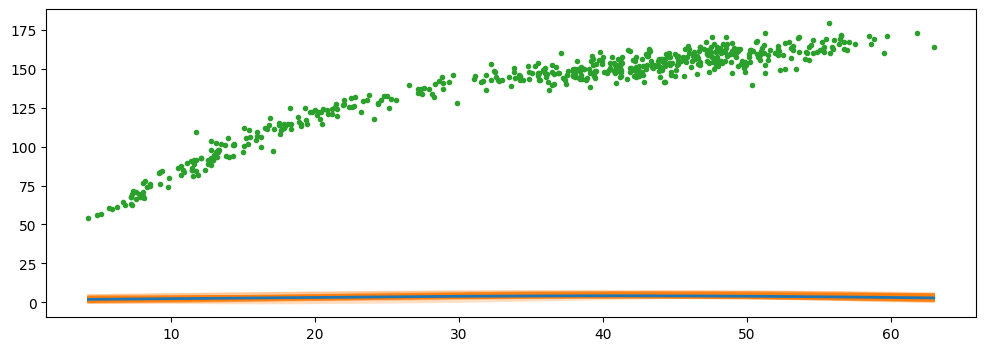

In [12]:
#set up plot
_, ax = plt.subplots(1, 1, figsize=(12, 4))
#plot raw data
ax.plot(howell.weight.values, howell.height.values, "C2.")

#grab posterior
f = az.extract(idata_hsgp, group="posterior", var_names="f")


idx = np.argsort(howell.weight.values)
#plot samples of the posterior
# Changed np.exp(f) to f directly since f now represents the mean of a Normal distribution
ax.plot(howell.weight.values[idx], f.values[idx,:100], alpha=0.25, color="C1")
#plot posterior mean
ax.plot(howell.weight.values[idx], f.values[idx].mean(1), color="C0", lw=2)

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

One thing I learned is that GPs can make use of custom changepoint covariance and mean functions in order to use conditional functionality.

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

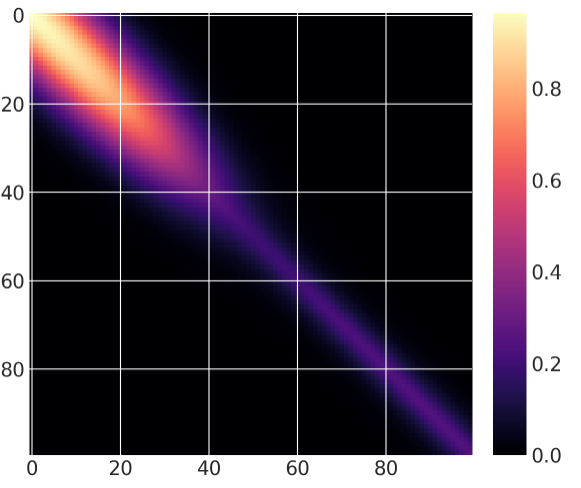

This is my favorite because it looks so different than all the other graphs we've looked at in this class, and it's also visually pleasing. It's showing something related to the gradual changepoint I think. There were other similar graphs in the article, but in this one, the change between the colors wasn't as sudden, it was more gradual, because it's a gradual changepoint function I guess.